In [1]:
import torch.nn.functional as F
from skimage.io import imsave
from PIL import Image, ImageOps
import numpy as np 
import argparse
import torch
import cv2
import pdb
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from typing import Dict, List
DEVICE='cuda:0'

In [2]:
def get_mean_stdinv(img):
    """
    Compute the mean and std for input image (make sure it's aligned with training)
    """

    mean=[123.675, 116.28, 103.53]
    std=[58.395, 57.12, 57.375]

    mean_img = np.zeros((img.shape))
    mean_img[:,:,0] = mean[0]
    mean_img[:,:,1] = mean[1]
    mean_img[:,:,2] = mean[2]
    mean_img = np.float32(mean_img)

    std_img = np.zeros((img.shape))
    std_img[:,:,0] = std[0]
    std_img[:,:,1] = std[1]
    std_img[:,:,2] = std[2]
    std_img = np.float64(std_img)

    stdinv_img = 1 / np.float32(std_img)

    return mean_img, stdinv_img

def numpy2tensor(img):
    """
    Convert numpy to tensor
    """
    img = torch.from_numpy(img).transpose(0,2).transpose(1,2).unsqueeze(0).float()
    return img

def prepare_input(img, device):
    """
    Convert numpy image into a normalized tensor (ready to do segmentation)
    """
    mean_img, stdinv_img = get_mean_stdinv(img)
    img_tensor = numpy2tensor(img).to(device)
    mean_img_tensor = numpy2tensor(mean_img).to(device)
    stdinv_img_tensor = numpy2tensor(stdinv_img).to(device)
    img_tensor = img_tensor - mean_img_tensor
    img_tensor = img_tensor * stdinv_img_tensor
    return img_tensor

In [3]:
model_file = '/home/jovyan/image-artifacts/baselines/PAL4VST/deployment/pal4vst/swin-large_upernet_unified_512x512/end2end.pt'
model = torch.load(model_file, weights_only=False).to(DEVICE)

/home/jovyan/conda/rf-solver/lib/python3.10/site-packages/torch/serialization.py:1434: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(


In [4]:
def load_jsonl(file_path: str) -> List[Dict]:
    """Load JSONL file and return list of samples."""
    samples = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line.strip()))
    return samples

In [5]:
# Load the JSONL data
jsonl_path = "/home/jovyan/image-artifacts/src/train/LLaMA-Factory/generated_predictions.jsonl"
samples = load_jsonl(jsonl_path)

# Create iterator over samples
sample_iter = iter(samples)
current_index = 0

print(f"✅ Loaded {len(samples)} samples from {jsonl_path}")
print("🔄 Ready to visualize! Run the next cell to see the first sample.")
print("💡 Re-run the next cell to advance to subsequent samples.")

✅ Loaded 728 samples from /home/jovyan/image-artifacts/src/train/LLaMA-Factory/generated_predictions.jsonl
🔄 Ready to visualize! Run the next cell to see the first sample.
💡 Re-run the next cell to advance to subsequent samples.


In [6]:
sample = next(sample_iter)

# Get image path
image_paths = sample['image']
if isinstance(image_paths, list):
    image_path = image_paths[0]
else:
    image_path = image_paths

image_path = '/home/jovyan/image-artifacts/src/train/LLaMA-Factory/'+image_path
# Load image
if os.path.exists(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_tensor = prepare_input(image_rgb, DEVICE).to(DEVICE)
    output = model(img_tensor)
    mask_np = (output.cpu().data.numpy()[0][0] * 255.0).astype(np.uint8)
    image_np = image_rgb.astype(np.uint8)

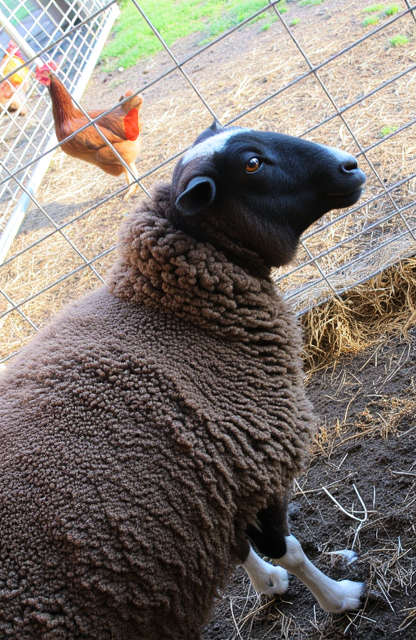

In [7]:
import numpy as np
from PIL import Image

# Example inputs
# image_np = ... # shape (H, W, 3), dtype uint8
# mask_np = ...  # shape (H, W), dtype uint8 or bool or int

# Convert image to PIL RGBA
image_pil = Image.fromarray(image_np).convert("RGBA")

# Create colored mask: red color with transparency
# First, create an empty (H, W, 4) RGBA array
overlay_np = np.zeros((mask_np.shape[0], mask_np.shape[1], 4), dtype=np.uint8)

# Define mask color and alpha
overlay_np[mask_np > 0] = [255, 0, 0, 128]  # Red with 50% opacity

# Convert overlay to PIL
overlay_pil = Image.fromarray(overlay_np, mode="RGBA")

# Composite the overlay on the original image
result = Image.alpha_composite(image_pil, overlay_pil)
result.show()


In [8]:
from datasets import load_dataset
from itertools import islice

# Option A: full dataset
ds = load_dataset("bczhou/LOKI", split="train")
print("Total:", len(ds))
for ex in ds[:5]:
    print(ex)

/home/jovyan/conda/rf-solver/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total: 4092
image
label


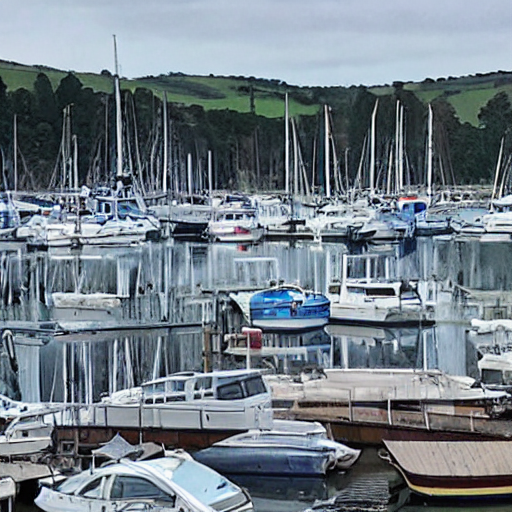


--- Metadata ---
Question: <image>


This is a fake image generated by an advanced AI model.

**Your Task:**

Please perform a detailed analysis explaining where this image seems inauthentic from the following perspectives:

1. **Global Perspective:**
   - Provide an overall explanation of why the entire image seems inauthentic.
   - Be specific and detailed in your explanation.
   - Reference any general visual cues that contribute to the inauthenticity.

2. **Regional Perspectives:**
   - Identify specific regions in the image that appear inauthentic.
   - For each region:
     - **Describe the location** or provide a reference to the region (e.g., "top-left corner," "the person's right hand," etc.).
     - **Explain in detail** why the region seems inauthentic.
     - Cite specific visual anomalies or inconsistencies observed in that region.

**Guidelines:**

- **Be Thorough:** Offer a comprehensive analysis covering all noticeable issues in both the global and regional perspective

In [21]:
# open_ended_vqa_viewer.ipynb

# 1. Import required modules
import json
from PIL import Image
from IPython.display import display
import os

# 2. Load the JSON configuration
json_path = "/home/jovyan/image-artifacts/data/loki/open_ended_vqa.json"
base_dir = os.path.dirname(json_path)

with open(json_path, "rb") as f:
    data = json.load(f)

# 3. Choose the first entry
sample = data[1]

# 4. Extract full image path
image_path = os.path.join(base_dir, sample["image_path"])

# 5. Load and display the image
if os.path.exists(image_path):
    image = Image.open(image_path)
    display(image)
else:
    print(f"Image file not found: {image_path}")

# 6. Print related metadata
print("\n--- Metadata ---")
print("Question:", sample.get("question", ""))
print("Problems (Global):", sample["problems"]["global"][0]["desc"])
print("Problems (Regional):")
for region in sample["problems"]["regional"]:
    print(" -", region["desc"])

In [23]:
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_tensor = prepare_input(image_rgb, DEVICE).to(DEVICE)
output = model(img_tensor)
mask_np = (output.cpu().data.numpy()[0][0] * 255.0).astype(np.uint8)
image_np = image_rgb.astype(np.uint8)

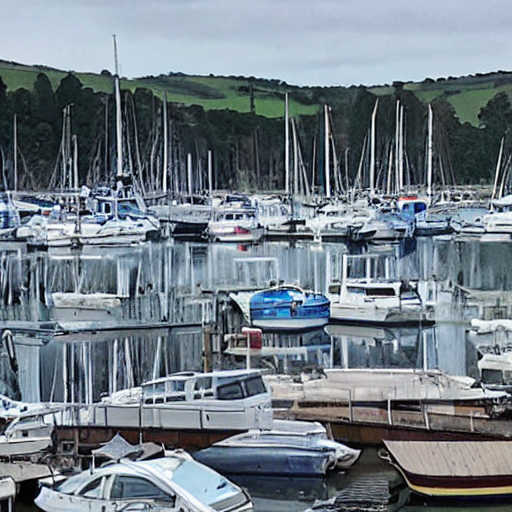

In [24]:
import numpy as np
from PIL import Image

# Example inputs
# image_np = ... # shape (H, W, 3), dtype uint8
# mask_np = ...  # shape (H, W), dtype uint8 or bool or int

# Convert image to PIL RGBA
image_pil = Image.fromarray(image_np).convert("RGBA")

# Create colored mask: red color with transparency
# First, create an empty (H, W, 4) RGBA array
overlay_np = np.zeros((mask_np.shape[0], mask_np.shape[1], 4), dtype=np.uint8)

# Define mask color and alpha
overlay_np[mask_np > 0] = [255, 0, 0, 128]  # Red with 50% opacity

# Convert overlay to PIL
overlay_pil = Image.fromarray(overlay_np, mode="RGBA")

# Composite the overlay on the original image
result = Image.alpha_composite(image_pil, overlay_pil)
result.show()
